# General Equilibrium and Counterfactual Analysis

(If GitHub truncates the output, you can see the full rendering in nbviewer:
Click [here](https://nbviewer.org/github/Kanato-Nakakuni/ComputationalMacro/blob/main/Lecture%20notes/Lec04_GE.ipynb).) 

- So far, we have solved the household’s problem by treating prices (wage and interest rates) as given.  
<br>
- In general equilibrium (GE), these prices are determined endogenously.  
    - s.t. Demand = Supply. Introducing a firm as an agent that demands inputs for production.
<br>
- Similarly, some of the government-related variables, such as tax rates, are also endogenously determined.  
<br>
- Why/when do we care about GE? To capture interaction btw. household behavior and macro variables.  
<br>
    - How much would the tax rate need to increase to finance a given policy (e.g., public pensions or family benefits)?  
    <br>
    - What would happen if the supply of college-educated workers increased due to more generous education subsidies? Would the skill premium rise or fall? And how would changes in the skill premium affect students’ education choices?  
<br>
- After today’s lecture: We will be able to solve a GE model with households, firms, and a government, in which factor prices and the tax rate are endogenously determined.  
<br>
- More specifically, we will answer the following questions through the lens of our quantitative models:
  - What are the macroeconomic implications of population aging? How does population aging affect GDP, aggregate labor supply, capital accumulation, wages, interest rates, and social security premium?
  - What are the macroeconomic implications of labor market and social security reforms, such as raising the retirement age or reducing public pension benefits? Do these policies improve household welfare?
---

### Setup

There are three sectors in the model:  
<br>
- Household  
<br>
- Firm  
<br>
- Government  

For notational convenience, we focus on a **stationary economy** and define a **stationary equilibrium**.

---

### Household

Households in this economy are similar to those discussed in the previous section, except that we now allow for **endogenous labor supply**, **public pensions**, and **labor income taxation**.  

- The economy is populated by overlapping generations.  
<br>
- A cohort of households enters the economy at age 20 ($j = 1$) in each period. These households are born without assets and live up to age 80 ($j = J = 61$). Each period, households derive utility from consumption $c_j$ and leisure $l_j$, and discount future utility by the factor $\beta$.  
<br>
- Each period, households choose how much to consume and save. Households are not allowed to borrow. Assets earn an interest rate $r$.  
<br>
- Until age 65 ($j = J_R = 46$), they also decide how many hours to work in the labor market, denoted by $h_j$. They earn gross labor income of $wh_j$, where $w$ is the market wage.  
<br>
- The time endowment is normalized to 1 and is allocated between work $(h_j)$ and leisure $(1 - h_j)$. Labor income is taxed at rate $\tau_w$.  
<br>
- After age $J_R$, households retire and receive a public pension benefit $p = \theta w$, where $\theta \in [0,1]$ is a parameter that governs the generosity of pension benefits.  
<br>
- $\mu(j)$ denotes the measure of households of age $j$, normalized such that $\sum_{j=1}^{J} \mu(j) = 1$.  
<br>
- If we assume no population growth, the mass of each generation is constant: $\mu(j) = \mu(j')$ for any $j, j'$.  

The problem is given by:

\begin{align*}
    & \max_{\{c_j\}_{j=1}^J, \{h_j\}_{j=1}^{J_R}, \{a_{j+1}\}_{j=1}^{J-1}} \sum_{j=1}^J \beta^{j-1} u(c_j, 1 - h_j) \\
    \text{s.t.} \quad
    c_j &= 
    \begin{cases}
        (1 - \tau_w) w h_j + (1 + r) a_j - a_{j+1} & \text{if } j \le J_R \\
        (1 + r) a_j - a_{j+1} + p & \text{if } j \in \{J_R+1, \dots, J-1\} \\
        (1 + r) a_j + p & \text{if } j = J
    \end{cases} \\
    & h_j \in [0, 1), \quad a_1 = 0, \quad a_{j+1} \ge 0, \quad c_j,l_j>0, \quad \forall j
\end{align*}

---

### Firm

- A representative firm that produces final goods $Y$ using the production function:  
$$
F(K, H) = K^\alpha H^{1 - \alpha},
$$
- $K$ and $H$ represent capital and labor inputs.  
<br>
- $\alpha$ governs capital's share in output.  
<br>
- Capital depreciates at rate $\delta$, and the firm bears this depreciation cost.

---

### Government

- The government provides public pensions to retirees, $p=\theta w$.  
<br>
- Finances these benefits by taxing labor income at rate $\tau_w$.  
---

## Stationary Equilibrium

We focus on a **stationary equilibrium**, in which aggregate variables — such as prices and the tax rate — are constant over time. The definition is as follows:

### **Definition (Stationary Equilibrium)**

Given $\theta$, a **stationary equilibrium** consists of household decision rules for consumption, savings, and labor supply $(c(j), a'(j), h(j))$, aggregate quantities $(K, H)$, prices $(r, w)$, and a tax rate $(\tau_w)$, such that:

1. **Household optimization**:  
   Households maximize their lifetime utility by solving the dynamic problem described above.

2. **Firm profit maximization**:  
   The firm’s first-order conditions are satisfied:
   $$
   r = \alpha \left( \frac{K}{H} \right)^{\alpha - 1} - \delta
   $$
   $$
   w = (1-\alpha) \left( \frac{K}{H} \right)^{\alpha}
   $$

3. **Factor market clearing**:
   $$
   K = \sum_{j=1}^{J} a(j) \mu(j)
   $$
   $$
   H = \sum_{j=1}^{J_R} h(j) \mu(j)
   $$

4. **Government budget constraint**:
   The labor tax rate balances the government budget:
   $$
   \tau_w w H = w \theta \underbrace{\sum_{j=J_R+1}^{J} \mu(j)}_{\equiv O}
   $$
   which implies:
   $$
   \tau_w = \theta \cdot \frac{O}{H}
   $$

---

### Algorithm

To solve the general equilibrium numerically, we work with two loops:  
- **Outer loop** for checking if markets are clear with given prices  
<br>
- **Inner loop** for solving household's problem and deriving factor supply

0. Make initial guesses for the tax rate $\tau_w$ and for factor prices $(r,w)$.  
<br>
1. (Inner loop) Solve the household problem and obtain household's decision rules given these prices and tax rate.  
<br>
2. Based on the household decision rules, compute the implied quantities, prices, and tax rate.  
<br>
3. (Outer loop) If these implied prices and tax rate are not close enough to their guesses, update their guesses and return to the step 2 (Inner loop).  
---

### Procedure: basic idea

1. Prepare a function named `solve_lifecycle` that returns household policy functions for savings and labor supply and lifetime utility (we will use this later for normative analysis), taking as inputs the prices and tax rate, $(r,w,\tau_w)$. You may set the number of grid points for asset as 200.  
<br>
2. Make initial guess for the tax rate and factor prices $(r,w)$.  You may start with initial guesses like $r=0.05$, $w=1.0$, and $\tau_w=0.1$.  
<br>
3. Using `solve_lifecycle`, go through Steps 2 and 3. You may check if  
    - $|r_g - r_m|/r_g < \varepsilon$  
    - $|w_g - w_m|/w_g < \varepsilon$  
    - $|\tau_{w,g} - \tau_{w,m}|/\tau_{w,g} < \varepsilon$, 
 by setting a convergence criteria $\varepsilon$ to $1.e-2$. Variables with subscript $g$ and $m$ refer to guessed values and model-implied ones.  
 <br>

For parameters, you may set:
- $\beta=0.98$  
- $\sigma=2.0$  
- $\omega=0.5$  
- $\theta=0.3$  
- $\alpha=0.33$  
- $\delta=0.1$

---

### A useful programming tip: `struct`

- (Quantitative) Model is usually complicated (e.g., involving many parameters and many procedures such as solving household problems, general equilibrium, calibration, etc.).  
<br>
- The best practice is to divide the procedures into separate scripts or functions (e.g., one that solves the household problem and another that solves the general equilibrium). This makes the code more readable and less error-prone.  
<br>
- But then, how should we handle the parameters?  
    - Define and assign parameter values in each file?  
    - Use global variables?  
<br>
- Using a `struct` is the typical way to deal with this.

In [61]:

# Basic formula
struct Parameters # Parameters is the name I set. Could be anything.
    β::Float64
    σ::Float64
    ω::Float64
    θ::Float64
    α::Float64
    δ::Float64
    J::Int
    JR::Int
    muj::Vector{Float64}   # 1 here refers to dimension of array
end

# Alternative way
# struct Parameters1{I<:Integer, F<:AbstractFloat} # Params is the name I set. Could be anything.
#     β::F
#     σ::F
#     ω::F
#     θ::F
#     α::F
#     δ::F
#     J::I
#     JR::I
#     muj::Vector{F}
# end

β=0.98
σ=2.0
ω=0.5
θ=0.3
α=0.33
δ=0.1
J=61
JR=46
muj=fill(1.0/J, J)
p = Parameters(β, σ, ω, θ, α, δ, J, JR, muj) # order matters here!
# @show p.β

# # Alternative way:
# # Set default struct Params ("definition of parameters to accept" = the return value, what this function does)
# Parameters1(; β=0.98, σ=2.0, ω=0.5, θ=0.3, α=0.33, δ=0.1, J=61, JR=46, muj=fill(1.0/J, J)) = Parameters1(β, σ, ω, θ, J, JR, muj)
# p = Parameters1()
# @show p.β
# # without this, you have to call Params like p = Params(β, σ, ω, θ, α, δ, J, JR, muj). ie., you should provide all the arguments with exact order.
# # with this default, you could simply state: p = Params() to store the parameter structure in p.
# # if you want to change some parameter value, you can simply write like p = Params(β=0.95), without re-stating all the other (irrelevant) parameters.
# # The leading ; tells Julia that they are keyword arguments, where order does not matter (≠ positional arguments)
# # if you want to use β, you need to type p.β


Parameters(0.98, 2.0, 0.5, 0.3, 0.33, 0.1, 61, 46, [0.01639344262295082, 0.01639344262295082, 0.01639344262295082, 0.01639344262295082, 0.01639344262295082, 0.01639344262295082, 0.01639344262295082, 0.01639344262295082, 0.01639344262295082, 0.01639344262295082  …  0.01639344262295082, 0.01639344262295082, 0.01639344262295082, 0.01639344262295082, 0.01639344262295082, 0.01639344262295082, 0.01639344262295082, 0.01639344262295082, 0.01639344262295082, 0.01639344262295082])

In [143]:
# set household optimization routine.
function solve_lifecycle(r,w,τ,p)
    
    ### inputs ###
    # r: interest rate
    # w: wage rate
    # τ: labor income tax rate 
    # p: struct, p = Parameters(β, σ, ω, θ, α, δ, J, JR, muj)
    ###############

    # discretization for asset space
    mina = 0.0 # lower bound (close to zero but not exactly (to avoid c=0))
    maxa = 15.0  # upper bound
    na   = 5000  # number of grid
    grida = collect(LinRange(mina,maxa,na)); # construct discretized asset space

    # value function and policy functions
    V = zeros(na,p.J); # value function V(a,j)
    Va = zeros(na);  # vector for grid search
    apol = zeros(na,p.J); # policy function for saving (value) a(a,J)
    apol_arg = ones(Int,na,p.J); # policy function for saving (index over asset space, grida)
    cpol = zeros(na,p.J)  # policy function for consumption c(a,J)
    hpol = zeros(na,p.J) # policy function for labor 

    penalty=-1.e+8

    # step 4: solving household problem by backward induction
    for jc in p.J:-1:1 # solve backward
        
        acc_start = 1 # for speed up
        v0=penalty

        for ac in 1:na

            if (jc==p.J) # compute final consumption given a
                c = (1.0+r)*grida[ac]+w*p.θ
                if (c>0)
                    V[ac,jc]=((c^p.ω)^(1.0-p.σ))/(1.0-p.σ) # leisure=1
                else # "punish" c<=0
                    V[ac,jc]=penalty
                end

                cpol[ac,jc]=c; # store it in policy function for c
                hpol[ac,jc]=0.0; # no work in retirement period
                
            else # working or retirement period (except for the final period)

                for acc in acc_start:na

                    # difference btw. working and retirement age; labor income, pension, and labor supply choice.
                    if (jc<=p.JR)
                        A = (1.0+r)*grida[ac]-grida[acc]
                        ATW = (1-τ)*w # AfterTaxWage
                        l = (1.0-p.ω) * (1.0 + A/ATW)
                        if (l>1) # l is bounded above by 1 (h is bounded below by 0)
                            l=1.0 # corner solution. we will check another condition l>0 below.
                        end
                        pension = 0.0
                    else # if (jc>JR && jc<J), retirement period
                        l = 1.0
                        pension = w*p.θ
                    end

                    c = (1-τ)*w*(1-l) + (1+r)*grida[ac]-grida[acc] + pension

                    if (c>0 && l>0)
                        Va[acc] = ((c^p.ω * l^(1.0-p.ω))^(1.0-p.σ))/(1.0-p.σ) + p.β*V[acc,jc+1]
                    else
                        Va[acc] = penalty
                    end

                    if (Va[acc]>v0)
                        v0=Va[acc]
                        acc_start=acc
                    else
                        break
                    end

                end

                arg = acc_start
                # arg = argmax(Va) # you may also use this instead

                apol_arg[ac,jc]=arg
                apol[ac,jc] = grida[arg]
                V[ac,jc] = Va[arg]

                if (jc<=JR) # working period
                    A = (1.0+r)*grida[ac]-grida[arg]
                    ATW = (1-τ)*w # AfterTaxWage
                    l = (1.0-p.ω) * (1.0 + A/ATW)
                    pension = 0.0
                else # if (jc>JR && jc<J), retirement period
                    l = 1.0
                    pension = w*p.θ
                end

                cpol[ac,jc]=(1.0-τ)*w*(1.0-l) + (1.0+r)*grida[ac]-grida[arg] + pension;
                hpol[ac,jc]=1.0-l
                
            end
        end
    end

    # find asset profile aj
    aj = zeros(p.J);
    hj = zeros(p.J);
    cj = zeros(p.J);

    arg_previous=1;
    aj[1]=grida[arg_previous]; # start from no-asset
    hj[1]=hpol[arg_previous,1]
    cj[1]=cpol[arg_previous,1]
    
    for jc in 2:p.J
        # find today's asset position
        arg = apol_arg[arg_previous,jc-1];
        # choices
        aj[jc]=grida[arg];
        hj[jc]=hpol[arg,jc]
        cj[jc]=cpol[arg,jc]

        arg_previous=arg # update
    end

    lifetime_utility = V[1,1]

    return aj,hj,cj,lifetime_utility # outputs
    
end

solve_lifecycle (generic function with 1 method)

In [144]:
# SOLVE GE
using Printf

# step 1. Make initial guesses
r = 0.02; w = 1.0; τ = 0.1;
# r = 0.03488; w = 1.041; τ = 0.2; # for Exercise 6

K = 1.0; H = 1.0; # to store the equilibrium outcomes later.

# convergence criteria and initial values for dif
ε =[1.e-2, 1.e-3, 1.e-3]; # for (r,w,τ)
d =[1.0, 1.0, 1.0]; # for (r,w,τ)

iter=1;
max_iter=1000; # for when something is wrong.
# max_iter=100; # for Exercise 6

# (optional) to visualize how it converges
r_iter   = zeros(max_iter)
w_iter   = zeros(max_iter)
τ_iter   = zeros(max_iter)

while any(d .> ε)

    # step 2. Household problems
    aj,hj,cj,~ = solve_lifecycle(r,w,τ,p)

    # step 3. Compute the implied aggregate variables and prices
    imp_K = sum(aj.*p.muj)
    imp_H = sum(hj.*p.muj)
    imp_τ = p.θ*sum(p.muj[p.JR+1:p.J])/imp_H

    # compute the implied prices with implied quantities (imp_K,imp_H)
    imp_r = p.α*(imp_K/imp_H)^(p.α-1.0) - p.δ
    imp_w = (1-p.α)*(imp_K/imp_H)^p.α

    # (optional) to visualize how they converge
    r_iter[iter]=r
    w_iter[iter]=w
    τ_iter[iter]=τ

    # step 4. Check if the guesses are right. If not, update.
    dif_r = abs(r-imp_r)/abs(r)
    dif_w = abs(w-imp_w)/w
    dif_τ = abs(τ-imp_τ)/τ

    d .= [dif_r,dif_w,dif_τ];

    # Update guess (a linear combination of guessed and implied values)
    adj=0.01; # ADJustment factor (weight)
    # adj=0.3; # for Exercise 6
    r = imp_r*adj + r*(1.0-adj)
    w = imp_w*adj + w*(1.0-adj)
    τ = imp_τ*adj + τ*(1.0-adj)

    K = imp_K; H = imp_H; # store the results

    # @show iter
    # @show maximum(d)

    iter+=1;

    if (iter>max_iter)
        break
    end

end
@show iter
@printf("dif_r = %.5f\ndif_w = %.5f\ndif_t = %.5f\n", d...)
@printf("K = %.5f\nH = %.5f\nr = %.5f\nw = %.5f\nτ = %.5f\n", K, H, r, w, τ)

iter = 634
dif_r = 0.00016
dif_w = 0.00012
dif_t = 0.00099
K = 1.40276
H = 0.36820
r = 0.03468
w = 1.04164
τ = 0.20016


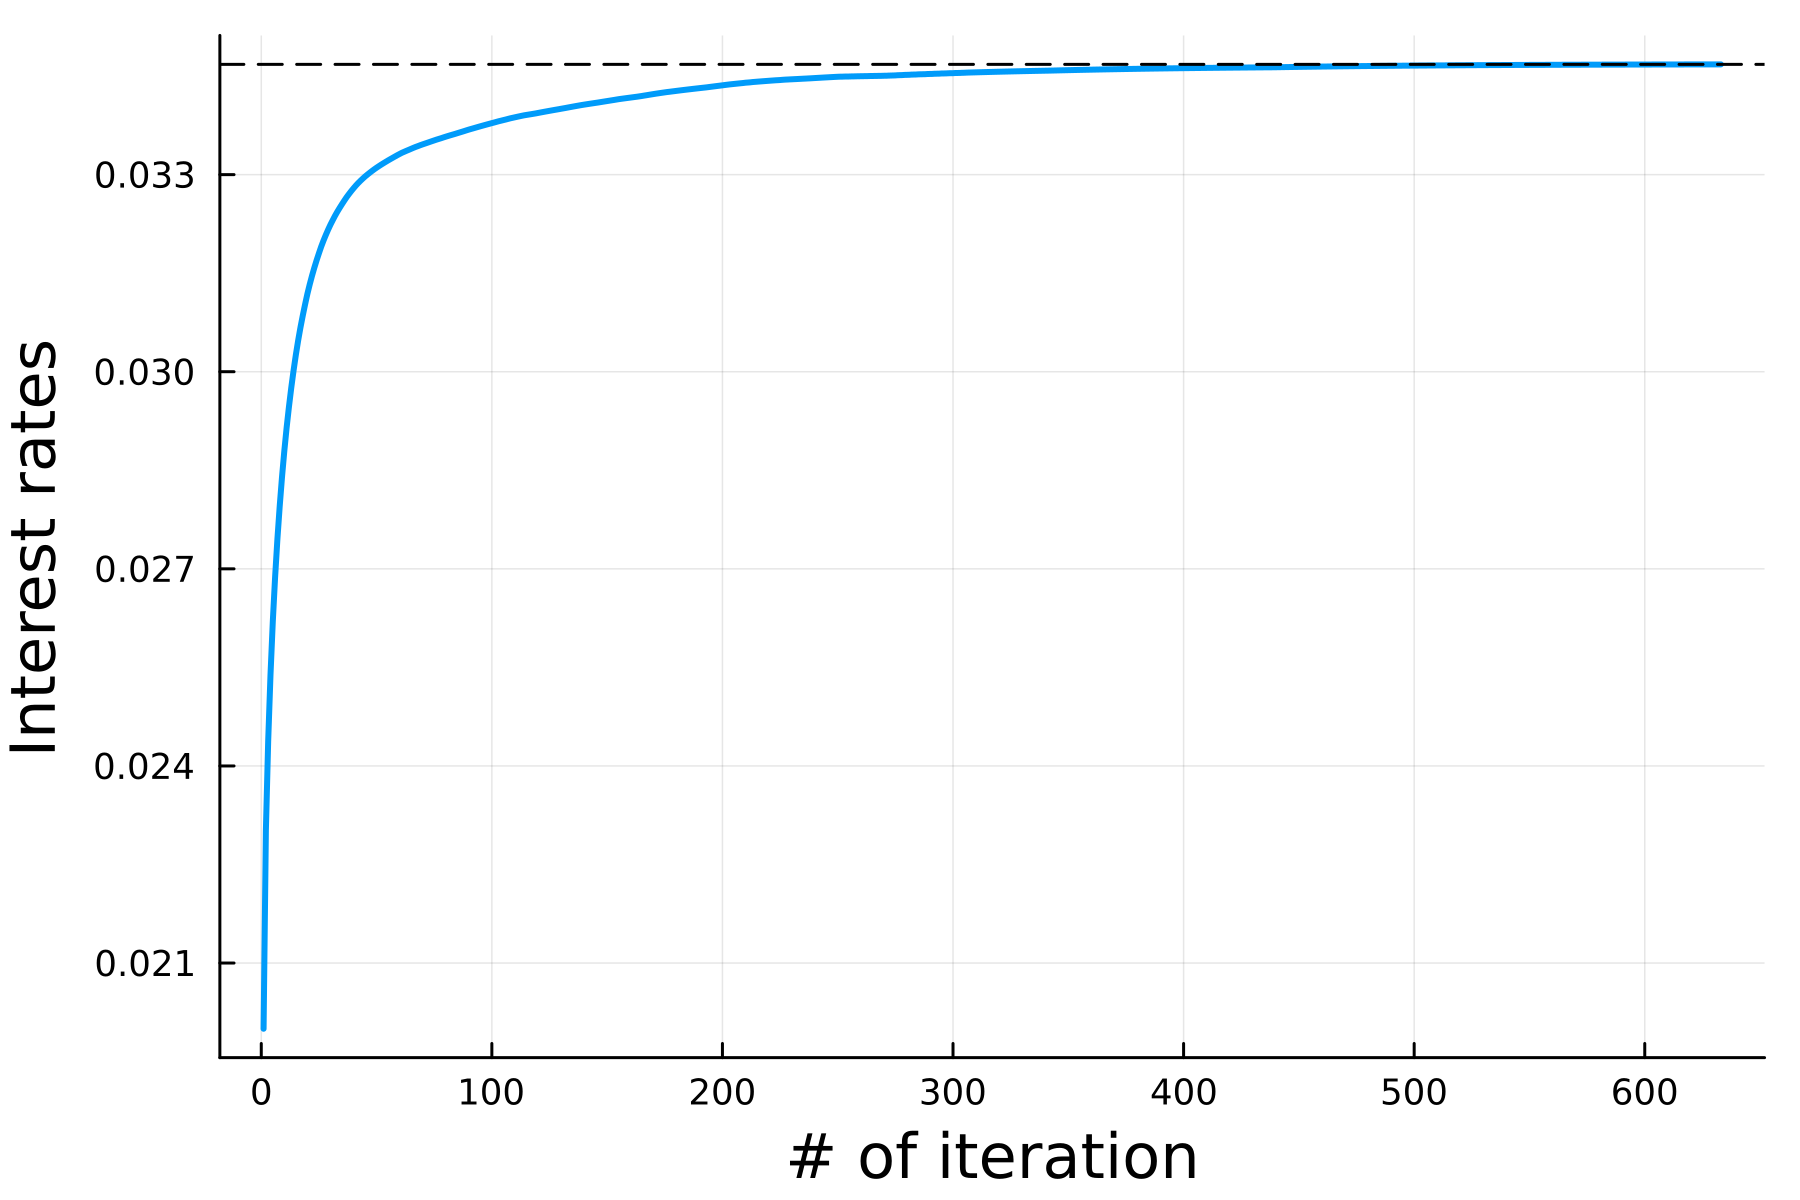

In [145]:
# plot interest rate convergence
using Plots
plot(1:iter-1, r_iter[1:iter-1],
    xlabel="# of iteration",
    ylabel="Interest rates",
    title="",
    lw=2,
    label="",
    dpi=300,
    xguidefont = font(14),   # font size for x-axis label
    yguidefont = font(14))
hline!([r], lw=1, lc=:black, ls=:dash, label="")  # horizontal line at y=r

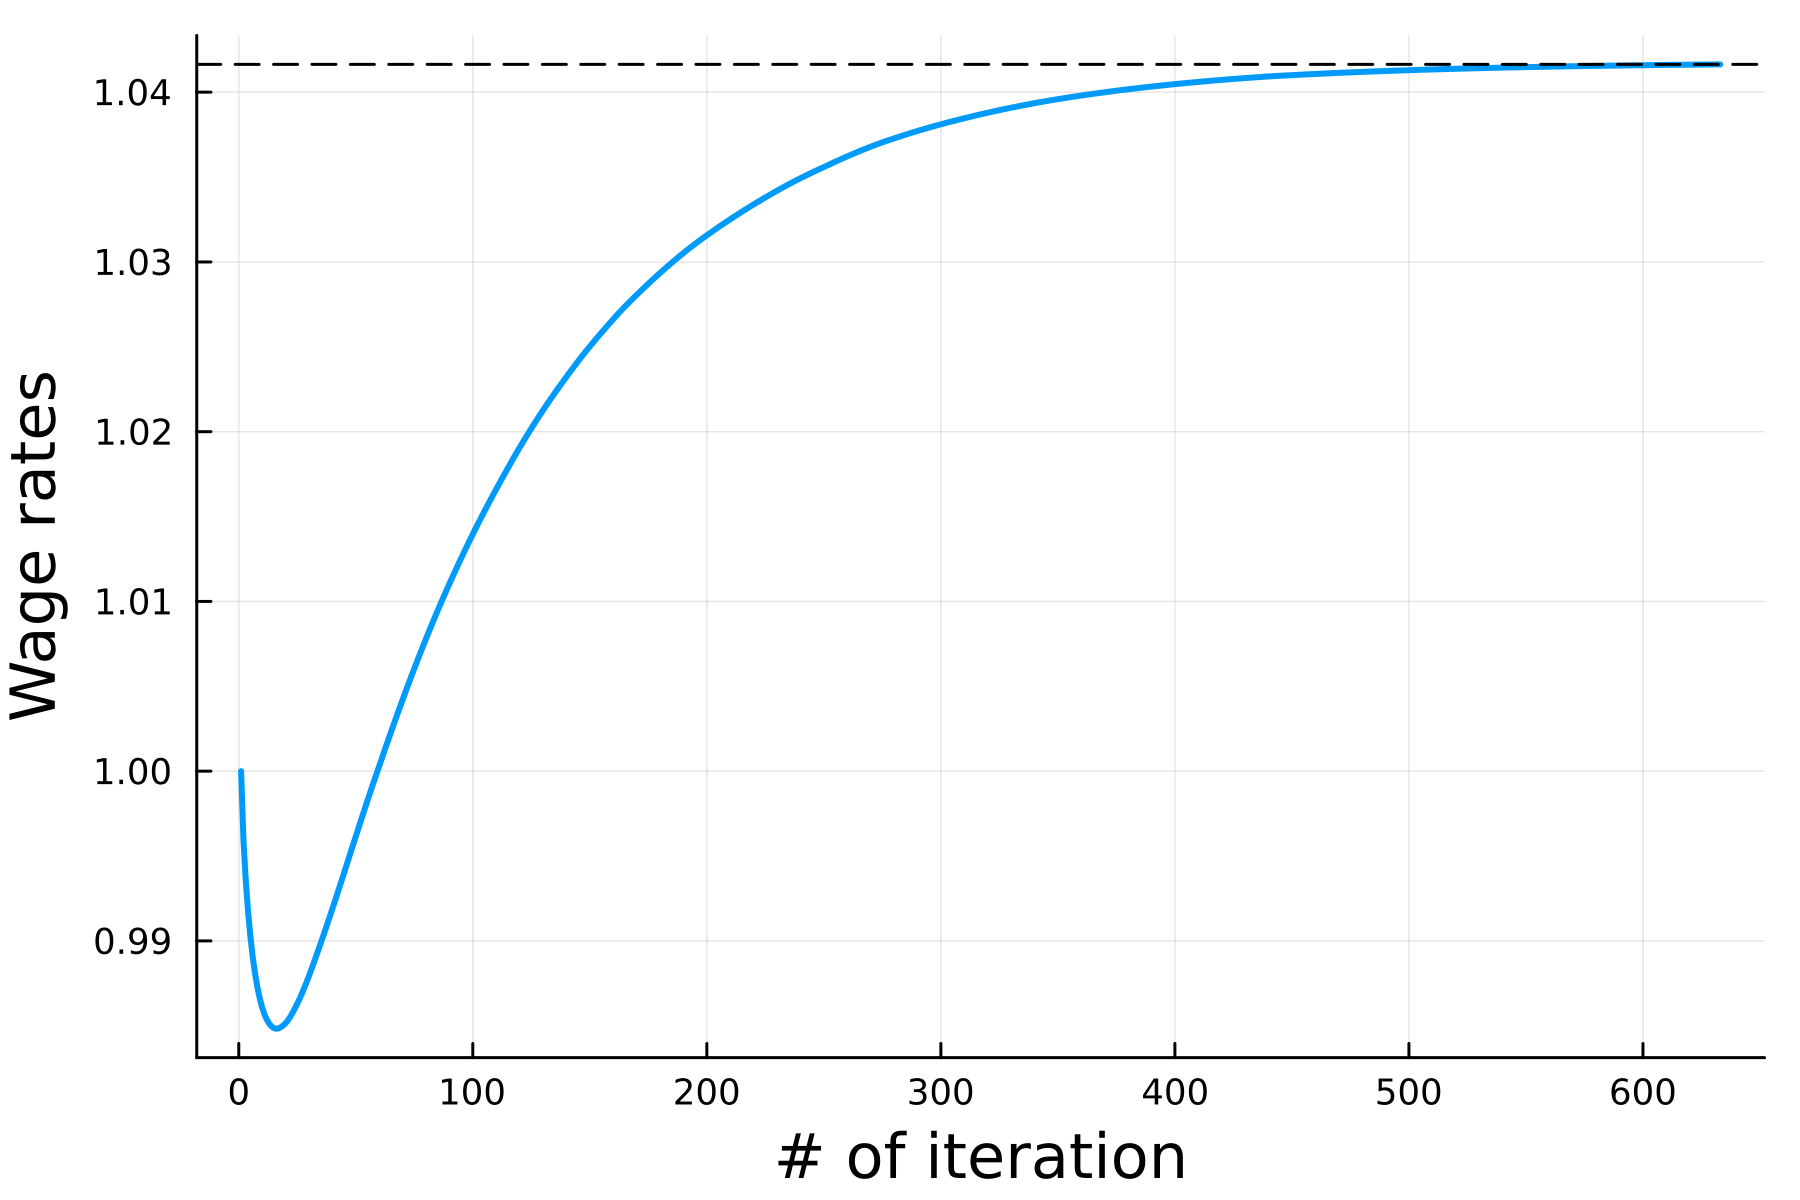

In [84]:
# plot wage rate convergence
plot(1:iter-1, w_iter[1:iter-1],
    xlabel="# of iteration",
    ylabel="Wage rates",
    title="",
    lw=2,
    label="",
    dpi=300,
    xguidefont = font(14),   # font size for x-axis label
    yguidefont = font(14))
hline!([w], lw=1, lc=:black, ls=:dash, label="")  # horizontal line at y=r

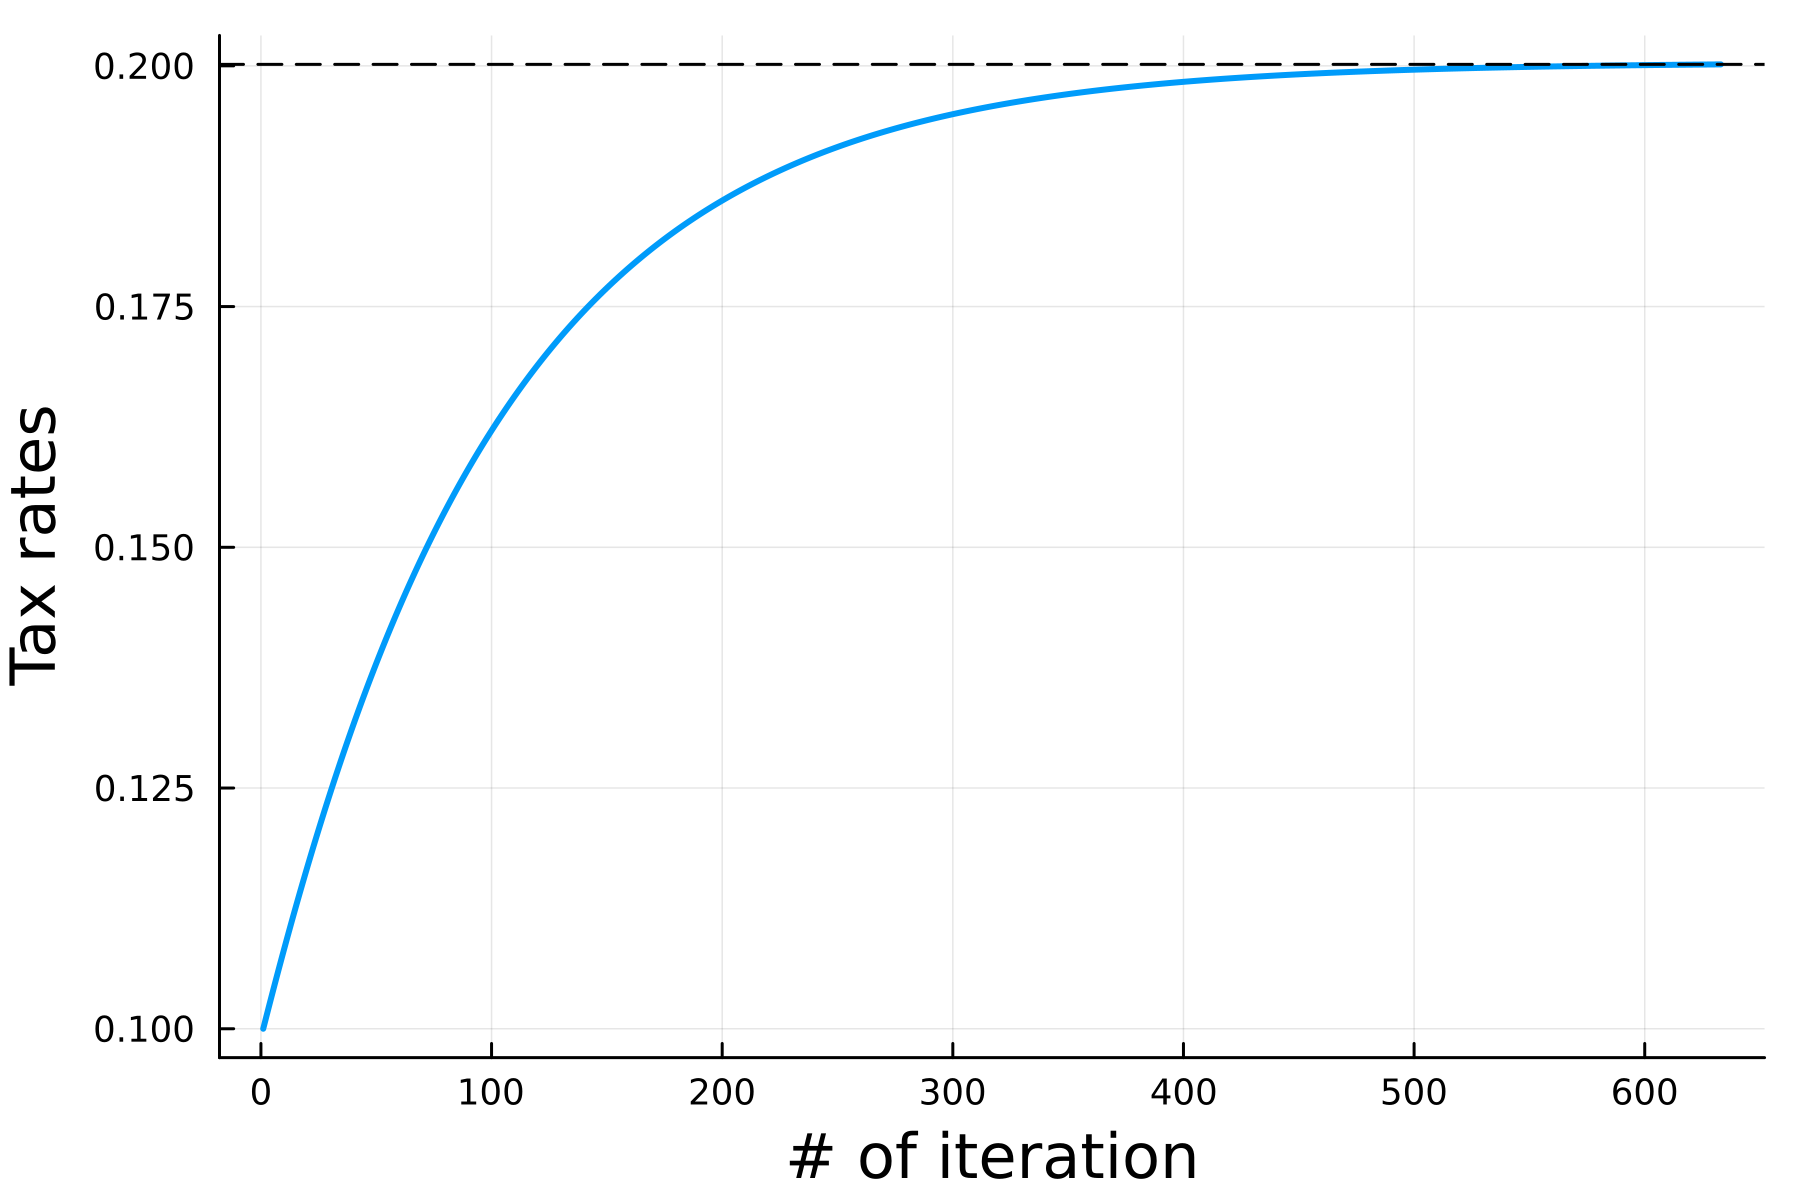

In [85]:
# plot tax rate convergence
plot(1:iter-1, τ_iter[1:iter-1],
    xlabel="# of iteration",
    ylabel="Tax rates",
    title="",
    lw=2,
    label="",
    dpi=300,
    xguidefont = font(14),   # font size for x-axis label
    yguidefont = font(14))
hline!([τ], lw=1, lc=:black, ls=:dash, label="")  # horizontal line at y=r

### **Counterfactual experiments**
Below, we will learn how to conduct counterfactual analysis using a quantitative model by working through a series of exercises step by step.

1. As a first step, construct a function `solve_GE` that takes an initial guess for the interest rate, wage, tax rate, and lifetime utility, together with the parameter struct `p`, $(r_0, w_0, \tau_0, p)$, as inputs, and returns GDP, aggregate capital, aggregate labor supply, the interest rate, the wage, and the tax rate.

In [86]:
function solve_GE(r,w,τ,p)

    # SOLVE GE

    K = 1.0; H = 1.0; V = 0;# to store the equilibrium outcomes later.

    # convergence criteria and initial values for dif
    ε =[1.e-2, 1.e-3, 1.e-3]; # for (r,w,τ)
    d =[1.0, 1.0, 1.0]; # for (r,w,τ)

    iter=1;
    max_iter=1000; # for when something is wrong.

    while any(d .> ε)

        # step 2. Household problems
        aj,hj,cj,V = solve_lifecycle(r,w,τ,p)

        # step 3. Compute the implied aggregate variables and prices
        imp_K = sum(aj.*p.muj)
        imp_H = sum(hj.*p.muj)
        imp_τ = p.θ*sum(p.muj[p.JR+1:p.J])/imp_H

        # compute the implied prices with implied quantities (imp_K,imp_H)
        imp_r = p.α*(imp_K/imp_H)^(p.α-1.0) - p.δ
        imp_w = (1-p.α)*(imp_K/imp_H)^p.α

        # step 4. Check if the guesses are right. If not, update.
        dif_r = abs(r-imp_r)/abs(r)
        dif_w = abs(w-imp_w)/w
        dif_τ = abs(τ-imp_τ)/τ

        d .= [dif_r,dif_w,dif_τ];

        # Update guess (a linear combination of guessed and implied values)
        adj=0.01; # ADJustment factor (weight)
        r = imp_r*adj + r*(1.0-adj)
        w = imp_w*adj + w*(1.0-adj)
        τ = imp_τ*adj + τ*(1.0-adj)

        K = imp_K; H = imp_H; # store the results

        # @show iter
        # @show maximum(d)

        iter+=1;

        if (iter>max_iter)
            break
        end

    end
    @show iter
    @printf("dif_r = %.5f\ndif_w = %.5f\ndif_t = %.5f\n", d...)
    @printf("K = %.5f\nH = %.5f\nr = %.5f\nw = %.5f\nτ = %.5f\n", K, H, r, w, τ)

    GDP = (K^p.α) * (H^(1.0-p.α))

    return GDP, K, H, r, w, τ, V
end

solve_GE (generic function with 1 method)

In [87]:
# check if the function works
r0=0.02; w0=1.0; τ0=0.1;
GDP, K, H, r, w, τ, V = solve_GE(r0,w0,τ0,p)

iter = 634
dif_r = 0.00016
dif_w = 0.00012
dif_t = 0.00099
K = 1.40276
H = 0.36820
r = 0.03468
w = 1.04164
τ = 0.20016


(0.5725106567840482, 1.4027559610282712, 0.3682042253443373, 0.03467829115335547, 1.0416398607637334, 0.2001556930058581, -74.63519640825672)

2. Macroeconomic implications of population aging. In the benchmark, we assume that $\mu(j)=1/J$, which corresponds to a zero population growth rate (approximately the current population growth rate in Germany). Now consider an aging population, in which the mass of the population is larger for older age cohorts. Specifically, the population masses at ages $j$ and $j+1$ satisfy

$$
\mu(j) = \mu(j+1)(1+g_n)
\Leftrightarrow
\mu(j+1) = \frac{\mu(j)}{1+g_n}.
$$

Suppose that the total population mass is normalized to one:

$$
\sum_{j=1}^{J} \mu(j) = 1.
$$

2.1. Create a function that returns the age distribution implied by the population growth rate $g_n$.

2.2. Compute the stationary equilibrium with a population growth rate of $-0.5\%$ ($\simeq$ Japan). Compare the results with the benchmark equilibrium with zero population growth. Explain the economic mechanisms behind the numerical differences between the two economies.

In [88]:
function age_distribution(g, J)

    muj = ones(J)

    for j = 1:J-1
        muj[j+1] = muj[j] / (1.0 + g)
    end

    # Normalize so that the total population mass is one
    muj ./= sum(muj)

    return muj

end

age_distribution (generic function with 1 method)

In [89]:
g = -0.005;
muj_aging = age_distribution(g,p.J);

In [90]:
# compute stationary equilibrium with the new mu
p_aging = Parameters(β, σ, ω, θ, α, δ, J, JR, muj_aging) # update parameter struct

r0=0.02; w0=1.0; τ0=0.2;
GDP_aging, K_aging, H_aging, r_aging, w_aging, τ_aging, V_aging = solve_GE(r0,w0,τ0,p_aging);

iter = 514
dif_r = 0.00034
dif_w = 0.00041
dif_t = 0.00099
K = 1.32794
H = 0.35040
r = 0.03517
w = 1.03954
τ = 0.23517


In [91]:
# display and compare the results 
# import Pkg
# Pkg.add("DataFrames")
using DataFrames

results_aging = DataFrame(
    Variable = ["GDP", "Capital", "Labor", "Interest rate", "Wage", "Tax rate"],
    Baseline = round.([GDP, K, H, r, w, τ], digits=3),
    Aging    = round.([GDP_aging, K_aging, H_aging, r_aging, w_aging, τ_aging], digits=3),
    Change   = round.([
        100 * (GDP_aging / GDP - 1),
        100 * (K_aging / K - 1),
        100 * (H_aging / H - 1),
        100 * (r_aging - r),
        100 * (w_aging / w - 1),
        100 * (τ_aging - τ)
    ], digits=4),
    Unit = ["%", "%", "%", "pp", "%", "pp"]
)

show(results_aging; eltypes=false)

6×5 DataFrame
 Row │ Variable       Baseline  Aging  Change   Unit 
─────┼───────────────────────────────────────────────
   1 │ GDP               0.573  0.544  -5.0002  %
   2 │ Capital           1.403  1.328  -5.3338  %
   3 │ Labor             0.368  0.35   -4.8355  %
   4 │ Interest rate     0.035  0.035   0.0492  pp
   5 │ Wage              1.042  1.04   -0.202   %
   6 │ Tax rate          0.2    0.235   3.501   pp

2.3. Now suppose that population growth remains zero, but life expectancy increases to age 100 (i.e., $J=80$).

In [97]:
# compute stationary equilibrium with new J
J_long = 80
muj_long = fill(1.0/J_long, J_long)
p_long = Parameters(β, σ, ω, θ, α, δ, J_long, JR, muj_long) # update parameter struct

r0=0.02; w0=1.0; τ0=0.2;
GDP_long, K_long, H_long, r_long, w_long, τ_long, V_long = solve_GE(r0,w0,τ0,p_long);

iter = 713
dif_r = 0.00228
dif_w = 0.00025
dif_t = 0.00098
K = 1.00715
H = 0.27493
r = 0.03818
w = 1.02863
τ = 0.46330


In [98]:
# display and compare the results 
using DataFrames

results_long = DataFrame(
    Variable = ["GDP", "Capital", "Labor", "Interest rate", "Wage", "Tax rate"],
    Baseline = round.([GDP, K, H, r, w, τ], digits=3),
    Aging    = round.([GDP_long, K_long, H_long, r_long, w_long, τ_long], digits=3),
    Change   = round.([
        100 * (GDP_long / GDP - 1),
        100 * (K_long / K - 1),
        100 * (H_long / H - 1),
        100 * (r_long - r),
        100 * (w_long / w - 1),
        100 * (τ_long - τ)
    ], digits=4),
    Unit = ["%", "%", "%", "pp", "%", "pp"]
)

show(results_long; eltypes=false)

6×5 DataFrame
 Row │ Variable       Baseline  Aging  Change    Unit 
─────┼────────────────────────────────────────────────
   1 │ GDP               0.573  0.422  -26.2915  %
   2 │ Capital           1.403  1.007  -28.2019  %
   3 │ Labor             0.368  0.275  -25.3319  %
   4 │ Interest rate     0.035  0.038    0.3503  pp
   5 │ Wage              1.042  1.029   -1.2492  %
   6 │ Tax rate          0.2    0.463   26.3146  pp

3. Compute the equilibrium with the retirement age extended to 69 $(J_R=50)$. Compare the results with the benchmark economy, in which the retirement age is 65 $(J_R=46)$. Compute **the welfare effects** of the policy. Explain the economic mechanisms behind the numerical differences between the two economies. 

### Welfare: Consumption-Equivalent Variation

So far, we have compared equilibrium outcomes such as GDP, capital, labor supply, wages, and interest rates. We may also want to ask whether a change in the economic environment makes households better or worse off.

Let lifetime utility in the benchmark economy be

$$
V_0 = \sum_{j=1}^{J} \beta^{j-1} u(c_j^0,l_j^0),
$$

and lifetime utility in a new economic environment be

$$
V_1 = \sum_{j=1}^{J} \beta^{j-1} u(c_j^1,l_j^1).
$$

We can compare $V_0$ and $V_1$ to determine which economy provides higher welfare. However, the magnitude of the difference, $V_1-V_0$, does not have an economically meaningful unit. For example, it is difficult to interpret what an increase in lifetime utility of 0.1 means.

A commonly used welfare measure is the **consumption-equivalent variation (CEV)**, which expresses the welfare change in units of consumption.

### **Definition (Consumption-Equivalent Variation)**

The consumption-equivalent variation, denoted by $\lambda$, is the proportional change in consumption at every age/period in the benchmark economy that makes the household indifferent between the benchmark and the new economic environment:

$$
V_1
=
\sum_{j=1}^{J}
\beta^{j-1}
u\left((1+\lambda)c_j^0,l_j^0\right).
$$

Thus, we change the entire benchmark consumption profile by the same proportion while keeping the benchmark leisure profile unchanged.

The interpretation is straightforward:

- If $\lambda>0$, the new economic environment improves welfare. The household would need an increase of $100\lambda\%$ in consumption at every age in the benchmark economy to be as well off as in the new economy.
- If $\lambda<0$, the new economic environment reduces welfare.
- If $\lambda=0$, the household is indifferent between the two economies.

---

In our model, period utility is

$$
u(c,l)
=
\frac{\left(c^\omega l^{1-\omega}\right)^{1-\sigma}}{1-\sigma}.
$$

Using this functional form,

$$
u\left((1+\lambda)c,l\right)
=
(1+\lambda)^{\omega(1-\sigma)}u(c,l).
$$

Therefore,

$$
V_1
=
(1+\lambda)^{\omega(1-\sigma)}V_0.
$$

Solving for $\lambda$, we obtain

$$
\boxed{
\lambda
=
\left(\frac{V_1}{V_0}\right)^{\frac{1}{\omega(1-\sigma)}}-1
}
$$

for $\sigma \neq 1$.

Hence, given lifetime utility in the benchmark economy, $V_0$, and lifetime utility in the counterfactual economy, $V_1$, we can directly compute the consumption-equivalent welfare change.

In [92]:
# compute stationary equilibrium with JR=50
JR_extended = 50
p_retire = Parameters(β, σ, ω, θ, α, δ, J, JR_extended, muj) # update parameter struct

r0=0.03; w0=1.05; τ0=0.15;
GDP_retire, K_retire, H_retire, r_retire, w_retire, τ_retire, V_retire = solve_GE(r0,w0,τ0,p_retire);
# compute cev
λ_retire = (V_retire/V)^(1.0/(p_retire.ω*(1.0-p_retire.σ))) - 1.0

iter = 346
dif_r = 0.00020
dif_w = 0.00030
dif_t = 0.00100
K = 1.44752
H = 0.37182
r = 0.03275
w = 1.04892
τ = 0.14564


0.04913722486635663

In [93]:
# display and compare the results 
using DataFrames

results_retire = DataFrame(
    Variable = ["GDP", "Capital", "Labor", "Interest rate", "Wage", "Tax rate", "CEV"],
    Baseline = round.([GDP, K, H, r, w, τ, 0.0], digits=3),
    Policy    = round.([GDP_retire, K_retire, H_retire, r_retire, w_retire, τ_retire, λ_retire], digits=3),
    Change   = round.([
        100 * (GDP_retire / GDP - 1),
        100 * (K_retire / K - 1),
        100 * (H_retire / H - 1),
        100 * (r_retire - r),
        100 * (w_retire / w - 1),
        100 * (τ_retire - τ),
        100 * (λ_retire),
    ], digits=4),
    Unit = ["%", "%", "%", "pp", "%", "pp", "pp"]
)

show(results_retire; eltypes=false)

7×5 DataFrame
 Row │ Variable       Baseline  Policy  Change   Unit 
─────┼────────────────────────────────────────────────
   1 │ GDP               0.573   0.582   1.7049  %
   2 │ Capital           1.403   1.448   3.1911  %
   3 │ Labor             0.368   0.372   0.9807  %
   4 │ Interest rate     0.035   0.033  -0.1928  pp
   5 │ Wage              1.042   1.049   0.6989  %
   6 │ Tax rate          0.2     0.146  -5.4514  pp
   7 │ CEV               0.0     0.049   4.9137  pp

4. Compute the equilibrium with a lower public pension replacement rate, say $\theta=0.2$. Compare the results with the benchmark economy, in which $\theta=0.3$. Explain the economic mechanisms behind the numerical differences between the two economies.

In [94]:
# compute stationary equilibrium with JR=50
θ_low = 0.2
p_low = Parameters(β, σ, ω, θ_low, α, δ, J, JR, muj) # update parameter struct

r0=0.028; w0=1.005; τ0=0.15;
GDP_low, K_low, H_low, r_low, w_low, τ_low, V_low = solve_GE(r0,w0,τ0,p_low);
# compute cev
λ_low = (V_low/V)^(1.0/(p_low.ω*(1.0-p_low.σ))) - 1.0

iter = 518
dif_r = 0.00049
dif_w = 0.00038
dif_t = 0.00099
K = 1.55933
H = 0.38121
r = 0.02843
w = 1.06609
τ = 0.12914


0.06021364166264176

In [95]:
# display and compare the results 
results_low = DataFrame(
    Variable = ["GDP", "Capital", "Labor", "Interest rate", "Wage", "Tax rate","CEV"],
    Baseline = round.([GDP, K, H, r, w, τ, 0.0], digits=3),
    Policy    = round.([GDP_low, K_low, H_low, r_low, w_low, τ_low, λ_low], digits=3),
    Change   = round.([
        100 * (GDP_low / GDP - 1),
        100 * (K_low / K - 1),
        100 * (H_low / H - 1),
        100 * (r_low - r),
        100 * (w_low / w - 1),
        100 * (τ_low - τ),
        100 * (λ_low),
    ], digits=4),
    Unit = ["%", "%", "%", "pp", "%", "pp","pp"]
)

show(results_low; eltypes=false)

7×5 DataFrame
 Row │ Variable       Baseline  Policy  Change   Unit 
─────┼────────────────────────────────────────────────
   1 │ GDP               0.573   0.607   5.99    %
   2 │ Capital           1.403   1.559  11.1618  %
   3 │ Labor             0.368   0.381   3.5319  %
   4 │ Interest rate     0.035   0.028  -0.6247  pp
   5 │ Wage              1.042   1.066   2.3477  %
   6 │ Tax rate          0.2     0.129  -7.1018  pp
   7 │ CEV               0.0     0.06    6.0214  pp

### **Decomposing the Welfare Effects**

- We can use the model to identify the sources of the welfare effects.

- From the household's perspective, which economic objects differ across the two economies? These include the interest rate, wage rate, tax rate, and policy parameters (e.g., pension benefits).

- We can decompose the welfare effects by computing the CEV while changing only one of these objects at a time.

Exercise 5. Decompose the welfare effects of public pension cut considered in exercise 4.

In [102]:
# Decomposing welfare effects of cutting pension benefit, using equilibrium prices and tax rate we computed.
# Recall that we named them as: r_low, w_low, τ_low, p_low
# Baseline: r, w, τ, V
# For convenience, define function to compute CEV (in %)
 function compute_CEV(V0,V1,p)

   λ = (V1/V0)^(1.0/(p.ω*(1.0-p.σ))) - 1.0

    return λ
 end

# Channel 1. Direct policy effect (change in θ)
~,~,~,V_p = solve_lifecycle(r,w,τ,p_low)
λ_p = compute_CEV(V,V_p,p)

# Channel 2. Interest rate
~,~,~,V_r = solve_lifecycle(r_low,w,τ,p)
λ_r = compute_CEV(V,V_r,p)

# Channel 3. Wage rate
~,~,~,V_w = solve_lifecycle(r,w_low,τ,p)
λ_w = compute_CEV(V,V_w,p)

# Channel 4. Tax rate
~,~,~,V_t = solve_lifecycle(r,w,τ_low,p)
λ_t = compute_CEV(V,V_t,p)

# Display welfare decomposition
welfare_decom = DataFrame(
    Channel = [
        "Direct policy effect",
        "Interest rate",
        "Wage rate",
        "Tax rate",
        "Total welfare effect"
    ],
    CEV = round.(100 .* [
        λ_p,
        λ_r,
        λ_w,
        λ_t,
        λ_low
    ], digits=3),
    Unit = ["%", "%", "%", "%", "%"]
)

show(welfare_decom; eltypes=false, summary=false)

 Row │ Channel               CEV     Unit 
─────┼────────────────────────────────────
   1 │ Direct policy effect  -2.391  %
   2 │ Interest rate         -1.518  %
   3 │ Wage rate              2.348  %
   4 │ Tax rate               8.239  %
   5 │ Total welfare effect   6.021  %

- The channel-specific welfare effects do not generally sum up to the total welfare effect because the model is nonlinear.

- The reason is that the effects interact: the welfare impact of changing one object (e.g., the wage) depends on the values of the other objects (e.g., the tax rate and interest rate).

In [106]:
println("Sum of each effect: ", round(100 * (λ_r + λ_w + λ_t + λ_p), digits=3), "%")
println("Total effect:       ", round(100 * λ_low, digits=3), "%")

Sum of each effect: 6.678%
Total effect:       6.021%


Exercise 6.

- We saw that computing the general equilibrium can take a long time because we need an outer loop to solve for equilibrium prices.

- Two naive ways to speed up the computation are:
  1. reducing the grid size, especially for assets
  2. using a more aggressive updating rule for aggregate quantities

- However, both approaches may come at the cost of accuracy and, in some cases, convergence.

- In the benchmark, we discretized the asset space using 5,000 grid points. Reduce the number of grid points to 500. To isolate the effect of the coarser grid, start from the "correct" initial guesses using the equilibrium values we have already computed. What happens to the computation time and the equilibrium results?

- In the benchmark, we updated aggregate quantities by placing a weight of 0.01 on the newly implied value:

$$
K^{new} = 0.01K_{implied} + 0.99K_{guessed}.
$$

Now use a larger updating weight, such as 0.1, 0.2, or 0.3. For example,

$$
K^{new} = 0.3K_{implied} + (1-0.3)K_{guessed}.
$$

What happens to the speed of convergence? Does the algorithm still converge?